In [6]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider
from scipy.signal import find_peaks
import numpy as np
initialise_or_create_database_at("./2026-05-11_SNSPD12.db")
import snspd
params = snspd.snspd('snspd12.yaml')

# Set up experiment
exp_name = 'SNSPD12_29_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 290


In [4]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd12.yaml')

Current where threshold (102mV = 17*0.006) first starts counting is -5uA. 

Set the absolute minimum trigger based on the last current before latching and see if that works for low currents.

[-3.5e-06] [0.072] [0.0576] [0.0144]
Peak voltage: [0.072]


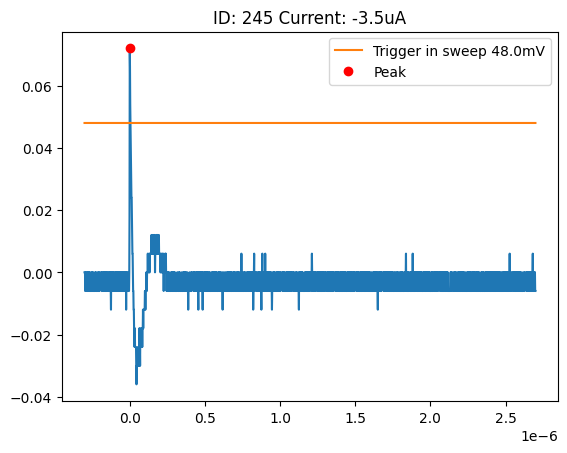

In [8]:
# write a routine to extract actual peak height from amplifier values 
ID = 245
data = load_by_id(ID).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']
current = data['yoko_current']['yoko_current']
trigger = data['trigger']['trigger'][0]
plt.plot(taxis, trace)
peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
plt.legend()
# plt.ylabel('Voltage (V)')
# plt.xlabel('Time (s)')
print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
print(f'Peak voltage: {trace[peaks]}')

In [9]:
def f(*args):
    return args

In [11]:
f('hello', 5)

('hello', 5)

In [21]:
def f(**kwargs):
    for k, val in kwargs.items():
        setattr(self, key, value) # how to unpack this 
    return a*5

In [22]:
f({a: 1, c:2})

NameError: name 'a' is not defined

In [ ]:
def trace_data(ID, plot=False):
    """ Returns the value of the voltage peaks
    """
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]

    if plot: 
        plt.plot(taxis, trace)
        peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
        plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
        plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
        plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
        plt.legend()

    
    output = {'peak_voltage_measured': trace[peaks],
             'peak_voltage': }
    
    
    return trace[peaks]

def generate_thresholds(t1=0.8, t2=0.3):
    """ Generate threshold data structure 
    """
    pass
        

In [74]:
# Calculate peak voltage compared to expected soemthign 
amplifiers: 
    amp1_gain: 
    amp2_gain: 
# def v_peak_value(ID, gain_list=None):
amp1_gain = self.amplifiers['amp1_gain'] if gain1 is None else gain1 

data = load_by_id(245).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']
current = data['yoko_current']['yoko_current']
trigger = data['trigger']['trigger'][0]

peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace)) 
# setting distance as length of trace means it will find one per trace

peak_voltage = properties['peak_heights']
# convert to dbm 
peak_dBm = 20*np.log(peak_voltage/1e-3)
amp1 = 50 # dB amplification 
amp2 = 45.5 # dB amplification 

v_device_dBm = peak_dBm - amp1 - amp2 
v_device = 1e-3*10**(v_device_dBm/20)
v_device

I = -3.5e-6
v_expected = I*34
print(v_device, v_expected)

0.0003174432662198576 -0.00011899999999999999


In [78]:
properties['peak_heights']

np.float64(0.072)

In [77]:
trace[peaks][0]

np.float64(0.072)